In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 6.6 MB/s eta 0:00:00


In [2]:
from sklearn.datasets import make_blobs, load_breast_cancer
from sklearn.model_selection import train_test_split
import mglearn
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
import numpy as np

Below is a synthetic two-class classification dataset

Text(0, 0.5, 'Feature 1')

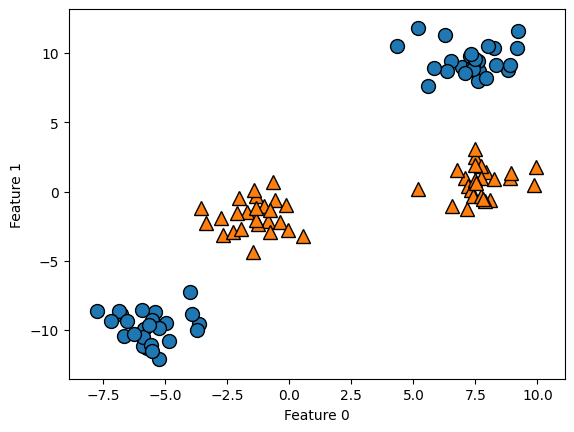

In [3]:
X, y = make_blobs(centers=4, random_state=8)
y = y % 2

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

A linear model for classification can only separate points using a line, and will not be able to do a very good job on this dataset.

Below Illustration confirms it.

In [4]:
linear_svm = LinearSVC()
linear_svm.fit(X, y)

LinearSVC()

Text(0, 0.5, 'Feature 1')

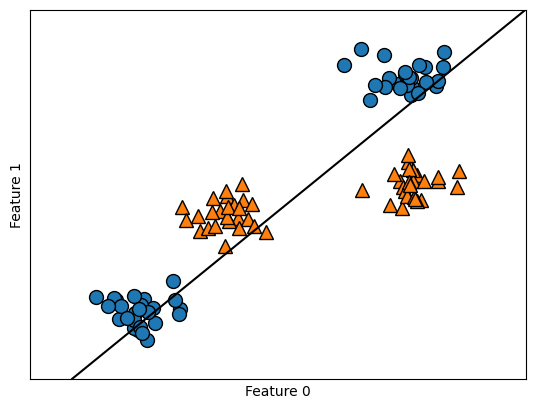

In [5]:
mglearn.plots.plot_2d_separator(linear_svm, X)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

linear models can be quite limiting in low-dimensional spaces, as lines and hyperplanes have limited flexibility. One way to make a linear model more flexible is by adding more features—for example, by adding interactions or polynomials of the input features.

Below expands the set of input features, by adding feature1 ** 2, the square of the second feature, as a new feature. Instead of representing each data point as a two-dimensional point, (feature0, feature1), we now represent it as a three-dimensional point, (feature0, feature1, feature1 ** 2).



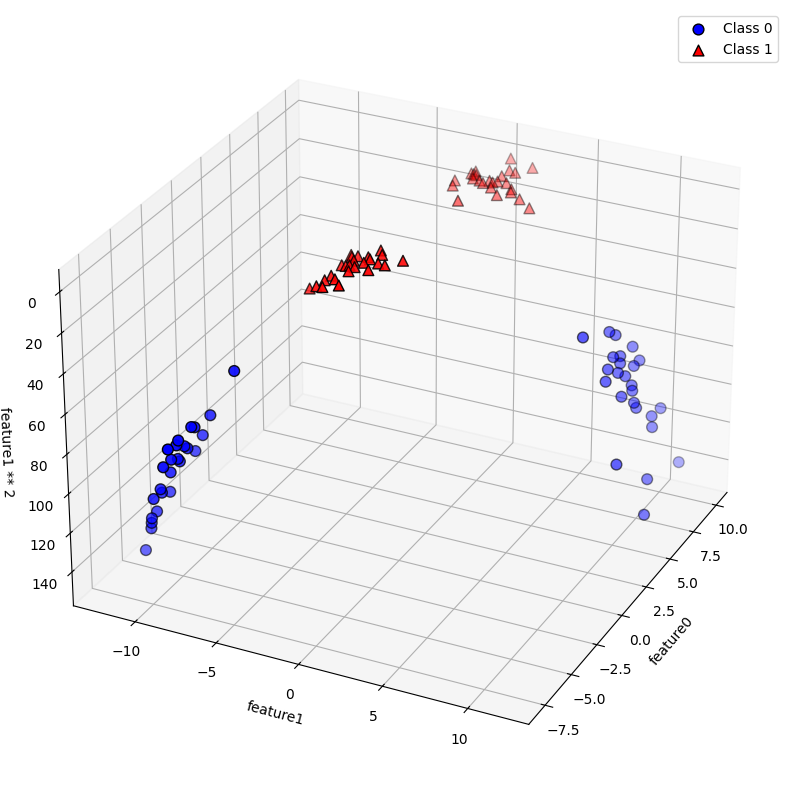

In [6]:
# add the squared second feature
X_new = np.hstack([X, X[:, 1:] ** 2])

from mpl_toolkits.mplot3d import Axes3D
figure = plt.figure(figsize=(10, 11))
# visualize in 3D - modern syntax
ax = figure.add_subplot(111, projection='3d')
ax.view_init(elev=-152, azim=-26)

# plot first all the points with y == 0, then all with y == 1
mask = y == 0
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
           s=60, edgecolor='k', label='Class 0')
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',
           s=60, edgecolor='k', label='Class 1')
ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature1 ** 2")
ax.legend()

plt.show()

In the new representation of the data, it is now indeed possible to separate the two classes using a linear model, a plane in three dimensions. We can confirm this by fitting a linear model to the augmented data.

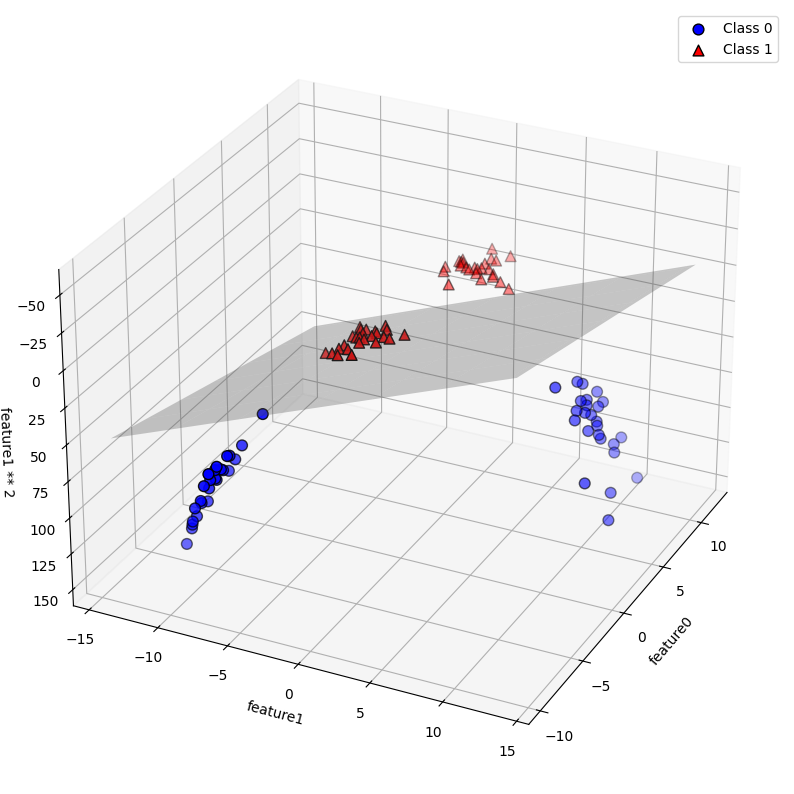

In [7]:
linear_svm_3d = LinearSVC().fit(X_new, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_

# show linear decision boundary
figure = plt.figure(figsize=(10, 11))
ax = figure.add_subplot(111, projection='3d')  # Modern way
ax.view_init(elev=-152, azim=-26)  # Modern way to set viewing angle

xx = np.linspace(X_new[:, 0].min() - 2, X_new[:, 0].max() + 2, 50)
yy = np.linspace(X_new[:, 1].min() - 2, X_new[:, 1].max() + 2, 50)

XX, YY = np.meshgrid(xx, yy)
ZZ = (coef[0] * XX + coef[1] * YY + intercept) / -coef[2]
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=0.3, color='gray')

# Plot the data points
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
           s=60, edgecolor='k', label='Class 0')
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',
           s=60, edgecolor='k', label='Class 1')

ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature1 ** 2")
ax.legend()

plt.show()

As a function of the original features, the linear SVM model is not actually linear anymore. It is not a line, but more of an ellipse(curved boundry), as we can see from the plot created below.

Text(0, 0.5, 'Feature 1')

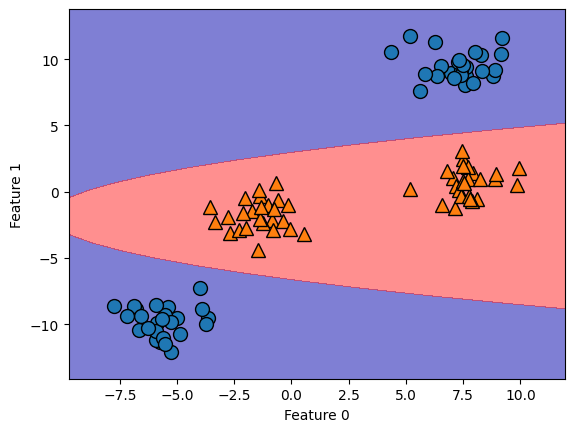

In [8]:
ZZ = YY ** 2
dec = linear_svm_3d.decision_function(np.c_[XX.ravel(), YY.ravel(), ZZ.ravel()])
plt.contourf(XX, YY, dec.reshape(XX.shape), levels=[dec.min(), 0, dec.max()],
             cmap=mglearn.cm2, alpha=0.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Below plot shows the result of training a support vector machine on a two-dimensional two-class dataset. The decision boundary is shown in black, and the support vectors are larger points with the wide outline. The following code creates this plot by training an SVM on the forge dataset.

In [9]:
from sklearn.svm import SVC

X, y = mglearn.tools.make_handcrafted_dataset()

svm = SVC(kernel='rbf', C=10, gamma=0.1)
svm.fit(X, y)


SVC(C=10, gamma=0.1)

Text(0, 0.5, 'Feature 1')

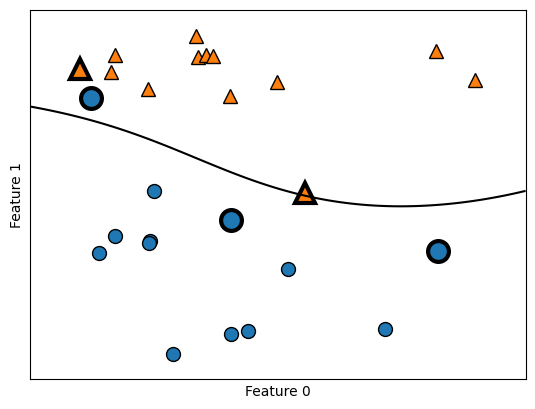

In [10]:
mglearn.plots.plot_2d_separator(svm, X, eps=.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
# plot support vectors
sv = svm.support_vectors_
# class labels of support vectors are given by the sign of the dual coefficients
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

The SVM yields a very smooth and nonlinear (not a straight line) boundary. We adjusted two parameters here: the C parameter and the gamma parameter.

The gamma parameter is the one shown in the formula given in the previous section, which corresponds to the inverse of the width of the Gaussian kernel. Intuitively, the gamma parameter determines how far the influence of a single training example reaches, with low values meaning corresponding to a far reach, and high values to a limited reach. In other words, the wider the radius of the Gaussian kernel, the further the influence of each training example. The C parameter is a regularization parameter, similar to that used in the linear models. It limits the importance of each point (or more precisely, their dual_coef_).

Below plots visualize what happens when these vary.

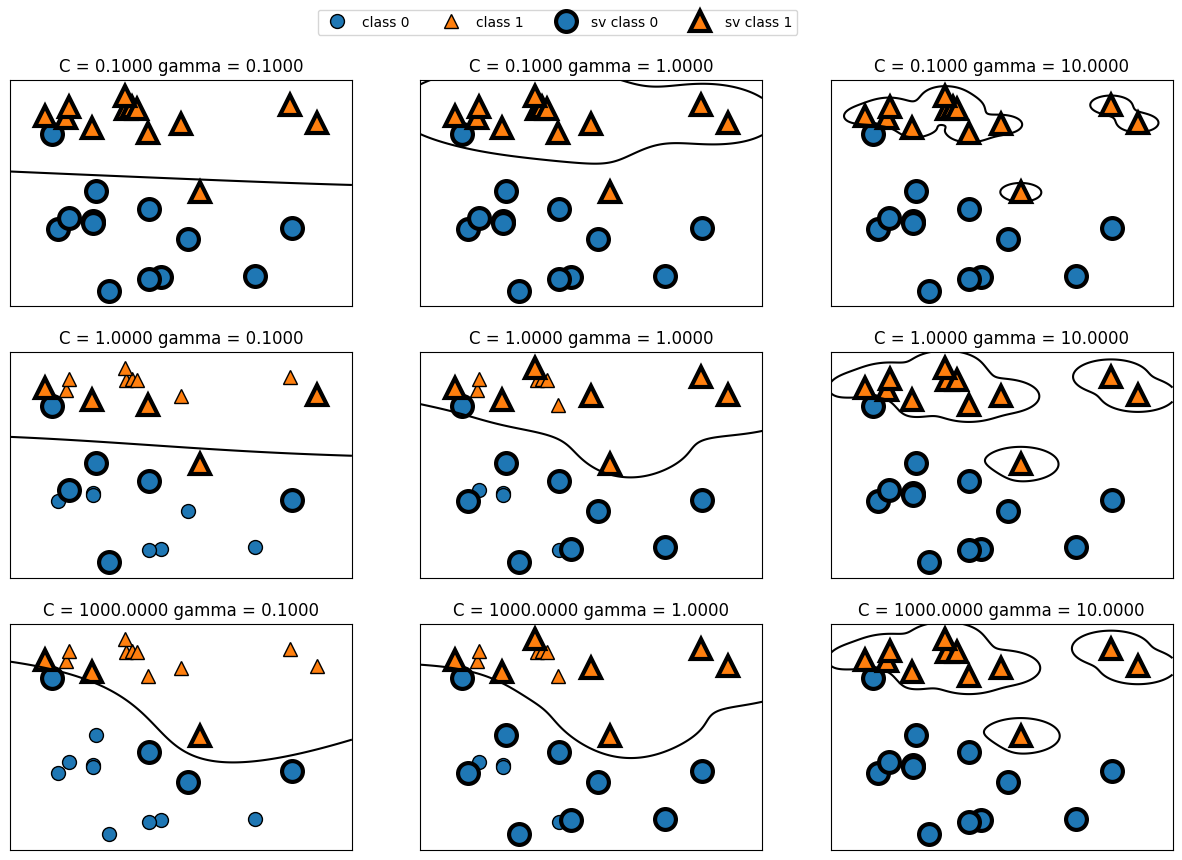

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1, 2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)

axes[0, 0].legend(["class 0", "class 1", "sv class 0", "sv class 1"],
                  ncol=4, loc=(.9, 1.2))

Going from left to right, increases the value of the parameter gamma from 0.1 to 10. A small gamma means a large radius for the Gaussian kernel, which means that many points are considered close by. This is reflected in very smooth decision boundaries on the left, and boundaries that focus more on single points further to the right. A low value of gamma means that the decision boundary will vary slowly, which yields a model of low complexity, while a high value of gamma yields a more complex model.

Going from top to bottom, increases the C parameter from 0.1 to 1000. As with the linear models, a small C means a very restricted model, where each data point can only have very limited influence. You can see that at the top left the decision boundary looks nearly linear, with the misclassified points barely having any influence on the line. Increasing C, as shown on the bottom left, allows these points to have a stronger influence on the model and makes the decision boundary bend to correctly classify them.